In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
(train_img, train_label), (test_img, test_label) = keras.datasets.mnist.load_data()

In [3]:
len(train_img)

60000

In [4]:
len(test_img)

10000

In [5]:
print(train_img.shape)
print(train_label.shape)

(60000, 28, 28)
(60000,)


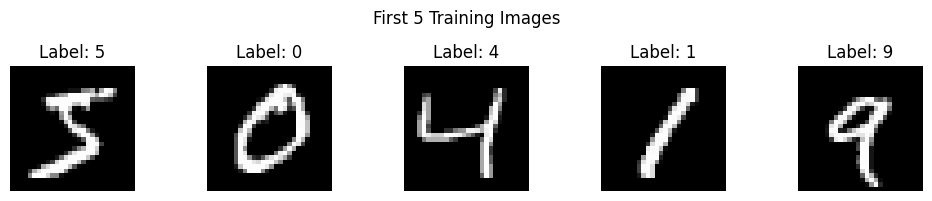

In [6]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_img[i], cmap='gray')
    plt.title(f'Label: {train_label[i]}')
    plt.axis('off')
plt.suptitle('First 5 Training Images', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
print('Min pixel value :', train_img.min())
print('Max pixel value :', train_img.max())
print('Image shape     :', train_img[0].shape)

Min pixel value : 0
Max pixel value : 255
Image shape     : (28, 28)


In [8]:
train_img = train_img / 255.0
test_img  = test_img  / 255.0

print('After normalization:')
print('Min pixel value :', train_img.min())
print('Max pixel value :', train_img.max())

After normalization:
Min pixel value : 0.0
Max pixel value : 1.0


In [9]:
train_img_flat = train_img.reshape(len(train_img), 28*28)
test_img_flat  = test_img.reshape(len(test_img),   28*28)

print('Flattened train shape:', train_img_flat.shape)
print('Flattened test  shape:', test_img_flat.shape)

Flattened train shape: (60000, 784)
Flattened test  shape: (10000, 784)


In [18]:
model = keras.Sequential([
    keras.layers.Dense(128, input_shape=(784,), activation='relu'),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax')  
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully!')

Model compiled successfully!


In [12]:
history = model.fit(
    train_img_flat, train_label,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8786 - loss: 0.4412 - val_accuracy: 0.9495 - val_loss: 0.1770
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9491 - loss: 0.1763 - val_accuracy: 0.9672 - val_loss: 0.1195
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9640 - loss: 0.1238 - val_accuracy: 0.9703 - val_loss: 0.1081
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9722 - loss: 0.0960 - val_accuracy: 0.9743 - val_loss: 0.0961
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0784 - val_accuracy: 0.9757 - val_loss: 0.0903
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9813 - loss: 0.0630 - val_accuracy: 0.9728 - val_loss: 0.0947
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9836 - loss: 0.0550 - val_accuracy: 0.9763 - val_loss: 0.0865
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.

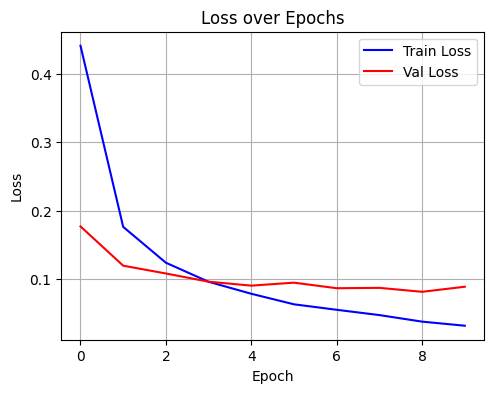

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='red')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

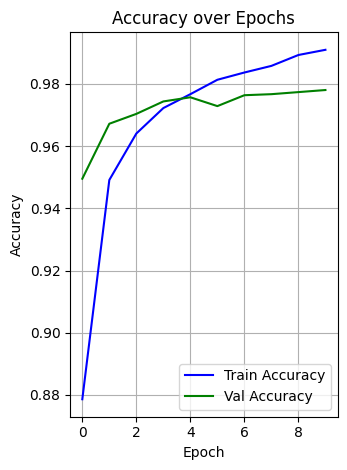

In [14]:
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(test_img_flat, test_label, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')

Test Loss     : 0.0826
Test Accuracy : 97.52%


In [16]:
predictions = model.predict(test_img_flat)
print('Predictions shape:', predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predictions shape: (10000, 10)


In [17]:
print('Predicted label :', np.argmax(predictions[0]))
print('Actual label    :', test_label[0])

Predicted label : 7
Actual label    : 7
